In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Use CPU
device = torch.device("cpu")

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [ ]:
def generate_gaussian_dataset(n_per_class=500, seed=42):

    np.random.seed(seed)

    # Different means
    means = np.array([
        [-3.0, -1.0],   # Class 0
        [ 3.0, -1.0],   # Class 1
        [ 0.0,  3.5]    # Class 2
    ])

    # Different standard deviations
    stds = np.array([
        [0.55, 0.75],   # Class 0
        [0.70, 0.50],   # Class 1
        [0.60, 0.65]    # Class 2
    ])

    X_list = []
    y_list = []

    for c in range(3):

        x = np.random.randn(n_per_class, 2)

        # Different variance for every class
        x[:, 0] = x[:, 0] * stds[c, 0]
        x[:, 1] = x[:, 1] * stds[c, 1]

        # Different mean
        x = x + means[c]

        X_list.append(x)
        y_list.append(
            np.full(n_per_class, c)
        )

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    return X, y


X_gaussian, y_gaussian = generate_gaussian_dataset()

print("Dataset shape:", X_gaussian.shape)
print("Labels shape:", y_gaussian.shape)
print("Class counts:", np.bincount(y_gaussian))

Dataset shape: (1500, 2)
Labels shape: (1500,)
Class counts: [500 500 500]


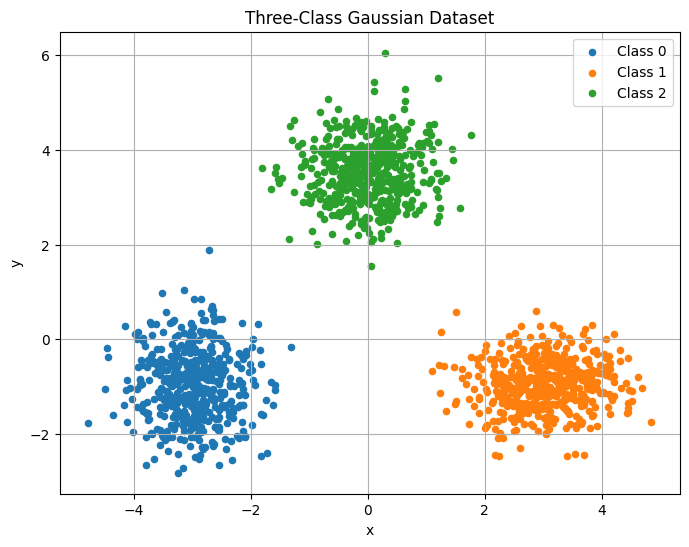

In [ ]:
def plot_dataset(X, y, title):

    plt.figure(figsize=(8, 6))

    for c in range(3):
        mask = (y == c)

        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            s=20,
            label=f"Class {c}"
        )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_dataset(
    X_gaussian,
    y_gaussian,
    "Three-Class Gaussian Dataset"
)

In [ ]:
def generate_spiral_dataset(
    n_per_class=500,
    noise=0.20,
    seed=42
):

    np.random.seed(seed)

    X_list = []
    y_list = []

    for c in range(3):

        r = np.linspace(0.1, 1.0, n_per_class)

        theta = (
            4.0 * np.pi * r
            + c * (2.0 * np.pi / 3.0)
        )

        # Add noise
        theta = theta + noise * np.random.randn(n_per_class)

        x1 = r * np.cos(theta)
        x2 = r * np.sin(theta)

        # Additional Gaussian noise
        x1 += noise * 0.15 * np.random.randn(n_per_class)
        x2 += noise * 0.15 * np.random.randn(n_per_class)

        X_class = np.column_stack((x1, x2))

        X_list.append(X_class)
        y_list.append(
            np.full(n_per_class, c)
        )

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    return X, y


X_spiral, y_spiral = generate_spiral_dataset()

print("Dataset shape:", X_spiral.shape)
print("Class counts:", np.bincount(y_spiral))

Dataset shape: (1500, 2)
Class counts: [500 500 500]


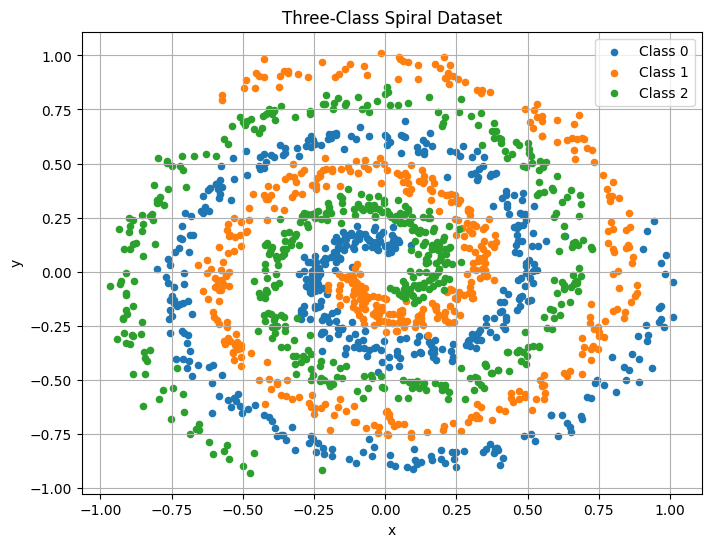

In [ ]:
plot_dataset(
    X_spiral,
    y_spiral,
    "Three-Class Spiral Dataset"
)

In [ ]:
def train_val_test_split_classwise(
    X,
    y,
    train_ratio=0.60,
    val_ratio=0.20,
    test_ratio=0.20,
    seed=42
):

    np.random.seed(seed)

    X_train = []
    y_train = []

    X_val = []
    y_val = []

    X_test = []
    y_test = []

    classes = np.unique(y)

    for c in classes:

        indices = np.where(y == c)[0]

        np.random.shuffle(indices)

        n = len(indices)

        n_train = int(train_ratio * n)
        n_val = int(val_ratio * n)

        train_idx = indices[:n_train]
        val_idx = indices[n_train:n_train+n_val]
        test_idx = indices[n_train+n_val:]

        X_train.append(X[train_idx])
        y_train.append(y[train_idx])

        X_val.append(X[val_idx])
        y_val.append(y[val_idx])

        X_test.append(X[test_idx])
        y_test.append(y[test_idx])

    X_train = np.vstack(X_train)
    y_train = np.concatenate(y_train)

    X_val = np.vstack(X_val)
    y_val = np.concatenate(y_val)

    X_test = np.vstack(X_test)
    y_test = np.concatenate(y_test)

    return (
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )

In [ ]:
(
    Xg_train, yg_train,
    Xg_val, yg_val,
    Xg_test, yg_test
) = train_val_test_split_classwise(
    X_gaussian,
    y_gaussian,
    seed=42
)


(
    Xs_train, ys_train,
    Xs_val, ys_val,
    Xs_test, ys_test
) = train_val_test_split_classwise(
    X_spiral,
    y_spiral,
    seed=42
)


print("Gaussian:")
print("Train:", Xg_train.shape)
print("Validation:", Xg_val.shape)
print("Test:", Xg_test.shape)

print()

print("Spiral:")
print("Train:", Xs_train.shape)
print("Validation:", Xs_val.shape)
print("Test:", Xs_test.shape)

Gaussian:
Train: (900, 2)
Validation: (300, 2)
Test: (300, 2)

Spiral:
Train: (900, 2)
Validation: (300, 2)
Test: (300, 2)


In [ ]:
def standardize_data(X_train, X_val, X_test):

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    X_train_scaled = (X_train - mean) / std
    X_val_scaled = (X_val - mean) / std
    X_test_scaled = (X_test - mean) / std

    return (
        X_train_scaled,
        X_val_scaled,
        X_test_scaled
    )

In [ ]:
def one_hot(y, num_classes=3):

    result = np.zeros(
        (len(y), num_classes)
    )

    result[np.arange(len(y)), y] = 1

    return result

In [ ]:
def tanh(x):
    return torch.tanh(x)


def tanh_derivative(x):

    t = torch.tanh(x)

    return 1 - t * t

In [ ]:
def softmax(x):

    x = x - torch.max(
        x,
        dim=1,
        keepdim=True
    ).values

    exp_x = torch.exp(x)

    return exp_x / torch.sum(
        exp_x,
        dim=1,
        keepdim=True
    )

In [ ]:
class FCNN:

    def __init__(
        self,
        input_size,
        hidden_sizes,
        output_size=3,
        learning_rate=0.01
    ):

        self.learning_rate = learning_rate

        self.layer_sizes = (
            [input_size]
            + hidden_sizes
            + [output_size]
        )

        self.weights = []
        self.biases = []

        # Xavier-style initialization
        for i in range(
            len(self.layer_sizes) - 1
        ):

            fan_in = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]

            limit = np.sqrt(
                6 / (fan_in + fan_out)
            )

            W = torch.empty(
                fan_in,
                fan_out,
                dtype=torch.float32
            ).uniform_(
                -limit,
                limit
            )

            b = torch.zeros(
                1,
                fan_out,
                dtype=torch.float32
            )

            self.weights.append(W)
            self.biases.append(b)

    # ------------------------------------------------
    # FORWARD PROPAGATION
    # ------------------------------------------------

    def forward(self, X):

        activations = [X]
        pre_activations = []

        A = X

        for i in range(
            len(self.weights)
        ):

            Z = (
                A @ self.weights[i]
                + self.biases[i]
            )

            pre_activations.append(Z)

            # Hidden layers
            if i < len(self.weights) - 1:

                A = tanh(Z)

            # Output layer
            else:

                A = softmax(Z)

            activations.append(A)

        return (
            A,
            activations,
            pre_activations
        )

    # ------------------------------------------------
    # SQUARED ERROR LOSS
    # ------------------------------------------------

    def loss(self, y_pred, y_true):

        error = y_pred - y_true

        return torch.mean(
            error * error
        )

    # ------------------------------------------------
    # BACKPROPAGATION
    # ------------------------------------------------

    def backward(
        self,
        y_true,
        activations,
        pre_activations
    ):

        n = y_true.shape[0]

        gradients_W = [
            None
        ] * len(self.weights)

        gradients_b = [
            None
        ] * len(self.biases)

        # Output layer
        y_pred = activations[-1]

        delta = (
            2.0 / n
        ) * (y_pred - y_true)

        # Backward through layers
        for i in reversed(
            range(len(self.weights))
        ):

            A_prev = activations[i]

            gradients_W[i] = (
                A_prev.T @ delta
            )

            gradients_b[i] = (
                torch.sum(
                    delta,
                    dim=0,
                    keepdim=True
                )
            )

            if i > 0:

                delta = (
                    delta
                    @ self.weights[i].T
                )

                delta = (
                    delta
                    * tanh_derivative(
                        pre_activations[i - 1]
                    )
                )

        return gradients_W, gradients_b

    # ------------------------------------------------
    # SGD UPDATE
    # ------------------------------------------------

    def update(
        self,
        gradients_W,
        gradients_b
    ):

        for i in range(
            len(self.weights)
        ):

            self.weights[i] -= (
                self.learning_rate
                * gradients_W[i]
            )

            self.biases[i] -= (
                self.learning_rate
                * gradients_b[i]
            )

    # ------------------------------------------------
    # PREDICTION
    # ------------------------------------------------

    def predict_proba(self, X):

        output, _, _ = self.forward(X)

        return output

    def predict(self, X):

        output = self.predict_proba(X)

        return torch.argmax(
            output,
            dim=1
        )

In [ ]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=1000,
    verbose=True
):

    X_train_t = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_val_t = torch.tensor(
        X_val,
        dtype=torch.float32
    )

    Y_train = torch.tensor(
        one_hot(y_train),
        dtype=torch.float32
    )

    Y_val = torch.tensor(
        one_hot(y_val),
        dtype=torch.float32
    )

    train_errors = []
    val_errors = []

    n = len(X_train)

    for epoch in range(epochs):

        # Shuffle training data
        indices = np.random.permutation(n)

        total_error = 0.0

        for idx in indices:

            # One example for SGD
            x = X_train_t[
                idx:idx+1
            ]

            y = Y_train[
                idx:idx+1
            ]

            # Forward
            output, activations, pre_activations = (
                model.forward(x)
            )

            # Error
            loss = model.loss(
                output,
                y
            )

            # Backpropagation
            gradients_W, gradients_b = (
                model.backward(
                    y,
                    activations,
                    pre_activations
                )
            )

            # SGD update
            model.update(
                gradients_W,
                gradients_b
            )

            total_error += loss.item()

        average_train_error = (
            total_error / n
        )

        # Validation error
        val_output = model.predict_proba(
            X_val_t
        )

        val_error = model.loss(
            val_output,
            Y_val
        ).item()

        train_errors.append(
            average_train_error
        )

        val_errors.append(
            val_error
        )

        if verbose and (
            epoch + 1
        ) % 100 == 0:

            print(
                f"Epoch {epoch+1:4d} | "
                f"Train Error = {average_train_error:.6f} | "
                f"Validation Error = {val_error:.6f}"
            )

    return train_errors, val_errors

In [ ]:
def accuracy_score_manual(
    model,
    X,
    y
):

    X_t = torch.tensor(
        X,
        dtype=torch.float32
    )

    predictions = model.predict(
        X_t
    ).numpy()

    accuracy = np.mean(
        predictions == y
    )

    return accuracy

In [ ]:
def confusion_matrix_manual(
    y_true,
    y_pred,
    num_classes=3
):

    cm = np.zeros(
        (num_classes, num_classes),
        dtype=int
    )

    for true, pred in zip(
        y_true,
        y_pred
    ):

        cm[true, pred] += 1

    return cm

In [ ]:
def classification_results(
    model,
    X,
    y,
    dataset_name="Dataset"
):

    X_t = torch.tensor(
        X,
        dtype=torch.float32
    )

    y_pred = model.predict(
        X_t
    ).numpy()

    cm = confusion_matrix_manual(
        y,
        y_pred
    )

    accuracy = np.mean(
        y == y_pred
    )

    print("\n", "=" * 50)
    print(dataset_name)
    print("=" * 50)

    print("\nConfusion Matrix:")
    print(cm)

    print(
        f"\nClassification Accuracy: "
        f"{accuracy * 100:.2f}%"
    )

    return cm, accuracy, y_pred

In [ ]:
def plot_confusion_matrix(
    cm,
    title
):

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.xticks(
        [0, 1, 2],
        ["Class 0", "Class 1", "Class 2"]
    )

    plt.yticks(
        [0, 1, 2],
        ["Class 0", "Class 1", "Class 2"]
    )

    for i in range(3):
        for j in range(3):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.show()

In [ ]:
def run_experiments(
    X_train,
    y_train,
    X_val,
    y_val,
    architectures,
    epochs=500,
    learning_rate=0.01
):

    results = {}

    for architecture in architectures:

        print("\n")
        print("=" * 60)
        print(
            "Architecture:",
            architecture
        )
        print("=" * 60)

        model = FCNN(
            input_size=2,
            hidden_sizes=architecture,
            output_size=3,
            learning_rate=learning_rate
        )

        train_errors, val_errors = train_model(
            model,
            X_train,
            y_train,
            X_val,
            y_val,
            epochs=epochs
        )

        val_accuracy = accuracy_score_manual(
            model,
            X_val,
            y_val
        )

        results[
            tuple(architecture)
        ] = {
            "model": model,
            "train_error": train_errors,
            "val_error": val_errors,
            "val_accuracy": val_accuracy
        }

        print(
            f"\nValidation Accuracy = "
            f"{val_accuracy * 100:.2f}%"
        )

    return results

In [ ]:
gaussian_architectures = [
    [4],
    [8],
    [16],
    [32]
]


gaussian_results = run_experiments(
    Xg_train,
    yg_train,
    Xg_val,
    yg_val,
    gaussian_architectures,
    epochs=500,
    learning_rate=0.02
)



Architecture: [4]
Epoch  100 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  200 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  300 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  400 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  500 | Train Error = 0.000000 | Validation Error = 0.000000

Validation Accuracy = 100.00%


Architecture: [8]
Epoch  100 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  200 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  300 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  400 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  500 | Train Error = 0.000000 | Validation Error = 0.000000

Validation Accuracy = 100.00%


Architecture: [16]
Epoch  100 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  200 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  300 | Train Error = 0.000000 | Validation Error = 0.000000
Epoch  400 | Train 

In [ ]:
spiral_architectures = [
    [8, 8],
    [16, 16],
    [32, 16],
    [32, 32]
]


spiral_results = run_experiments(
    Xs_train,
    ys_train,
    Xs_val,
    ys_val,
    spiral_architectures,
    epochs=1000,
    learning_rate=0.02
)



Architecture: [8, 8]
Epoch  100 | Train Error = 0.206436 | Validation Error = 0.215020
Epoch  200 | Train Error = 0.151879 | Validation Error = 0.129634
Epoch  300 | Train Error = 0.144224 | Validation Error = 0.137287
Epoch  400 | Train Error = 0.142040 | Validation Error = 0.120094
Epoch  500 | Train Error = 0.148665 | Validation Error = 0.146584
Epoch  600 | Train Error = 0.136355 | Validation Error = 0.133710
Epoch  700 | Train Error = 0.158280 | Validation Error = 0.150405
Epoch  800 | Train Error = 0.166829 | Validation Error = 0.174858
Epoch  900 | Train Error = 0.173397 | Validation Error = 0.173211
Epoch 1000 | Train Error = 0.164380 | Validation Error = 0.160350

Validation Accuracy = 63.00%


Architecture: [16, 16]
Epoch  100 | Train Error = 0.220096 | Validation Error = 0.217190
Epoch  200 | Train Error = 0.200431 | Validation Error = 0.200781
Epoch  300 | Train Error = 0.116632 | Validation Error = 0.120087
Epoch  400 | Train Error = 0.086496 | Validation Error = 0.09207

In [31]:
def print_architecture_results(
    results
):

    print("\n")
    print("=" * 60)
    print("ARCHITECTURE COMPARISON")
    print("=" * 60)

    print(
        f"{'Architecture':<25}"
        f"{'Final Val Error':<20}"
        f"{'Val Accuracy':<15}"
    )

    print("-" * 60)

    for architecture, result in results.items():

        final_error = (
            result["val_error"][-1]
        )

        accuracy = (
            result["val_accuracy"]
        )

        print(
            f"{str(architecture):<25}"
            f"{final_error:<20.6f}"
            f"{accuracy*100:<15.2f}"
        )


print("GAUSSIAN RESULTS")
print_architecture_results(
    gaussian_results
)

print("\nSPIRAL RESULTS")
print_architecture_results(
    spiral_results
)

GAUSSIAN RESULTS


ARCHITECTURE COMPARISON
Architecture             Final Val Error     Val Accuracy   
------------------------------------------------------------
(4,)                     0.000000            100.00         
(8,)                     0.000000            100.00         
(16,)                    0.000000            100.00         
(32,)                    0.000000            100.00         

SPIRAL RESULTS


ARCHITECTURE COMPARISON
Architecture             Final Val Error     Val Accuracy   
------------------------------------------------------------
(8, 8)                   0.160350            63.00          
(16, 16)                 0.051137            90.67          
(32, 16)                 0.044840            93.00          
(32, 32)                 0.029398            94.33          


In [32]:
def select_best_architecture(
    results
):

    best_architecture = max(
        results,
        key=lambda arch:
        results[arch]["val_accuracy"]
    )

    best_result = results[
        best_architecture
    ]

    return (
        best_architecture,
        best_result["model"]
    )


best_gaussian_architecture, best_gaussian_model = (
    select_best_architecture(
        gaussian_results
    )
)

best_spiral_architecture, best_spiral_model = (
    select_best_architecture(
        spiral_results
    )
)


print(
    "Best Gaussian architecture:",
    best_gaussian_architecture
)

print(
    "Best Spiral architecture:",
    best_spiral_architecture
)

Best Gaussian architecture: (4,)
Best Spiral architecture: (32, 32)


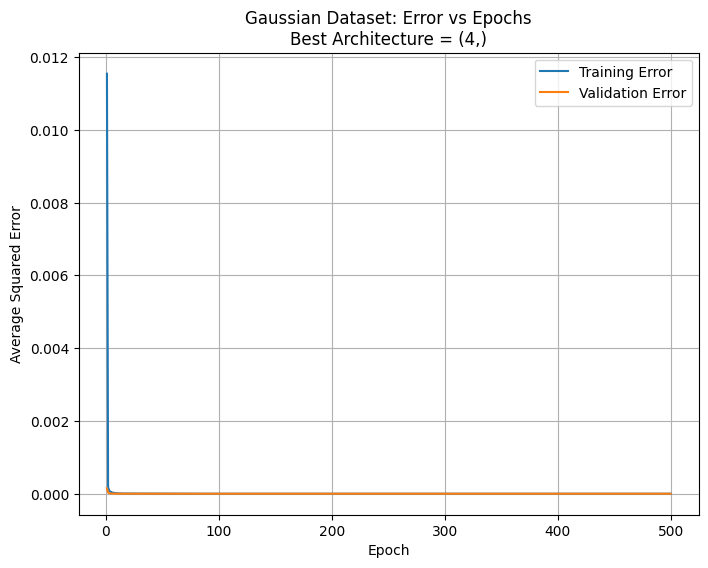

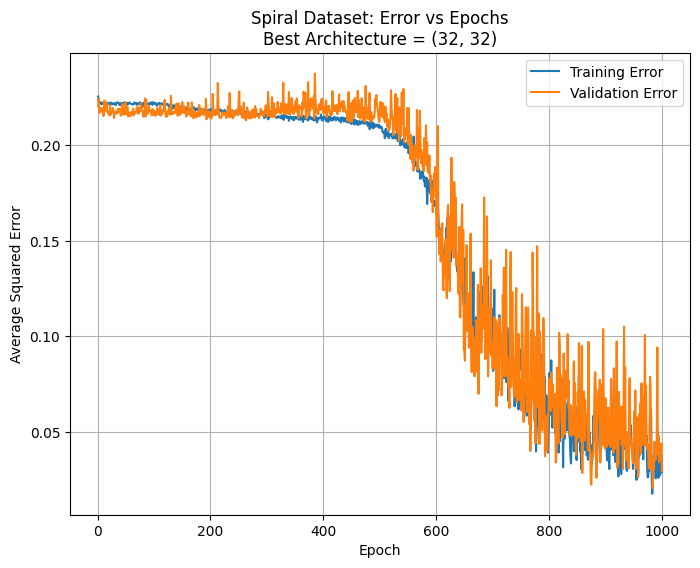

In [33]:
def plot_best_error(
    result,
    architecture,
    dataset_name
):

    plt.figure(figsize=(8, 6))

    epochs = np.arange(
        1,
        len(result["train_error"]) + 1
    )

    plt.plot(
        epochs,
        result["train_error"],
        label="Training Error"
    )

    plt.plot(
        epochs,
        result["val_error"],
        label="Validation Error"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Average Squared Error")

    plt.title(
        f"{dataset_name}: Error vs Epochs\n"
        f"Best Architecture = {architecture}"
    )

    plt.legend()
    plt.grid(True)
    plt.show()


plot_best_error(
    gaussian_results[
        tuple(best_gaussian_architecture)
    ],
    best_gaussian_architecture,
    "Gaussian Dataset"
)


plot_best_error(
    spiral_results[
        tuple(best_spiral_architecture)
    ],
    best_spiral_architecture,
    "Spiral Dataset"
)

In [34]:
def plot_decision_regions(
    model,
    X_train,
    y_train,
    title
):

    x_min = X_train[:, 0].min() - 0.5
    x_max = X_train[:, 0].max() + 0.5

    y_min = X_train[:, 1].min() - 0.5
    y_max = X_train[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            300
        ),
        np.linspace(
            y_min,
            y_max,
            300
        )
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    grid_t = torch.tensor(
        grid,
        dtype=torch.float32
    )

    predictions = (
        model.predict(grid_t)
        .numpy()
    )

    predictions = predictions.reshape(
        xx.shape
    )

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.25,
        levels=[-0.5, 0.5, 1.5, 2.5]
    )

    for c in range(3):

        mask = y_train == c

        plt.scatter(
            X_train[mask, 0],
            X_train[mask, 1],
            s=15,
            label=f"Class {c}"
        )

    plt.xlabel("x")
    plt.ylabel("y")

    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()

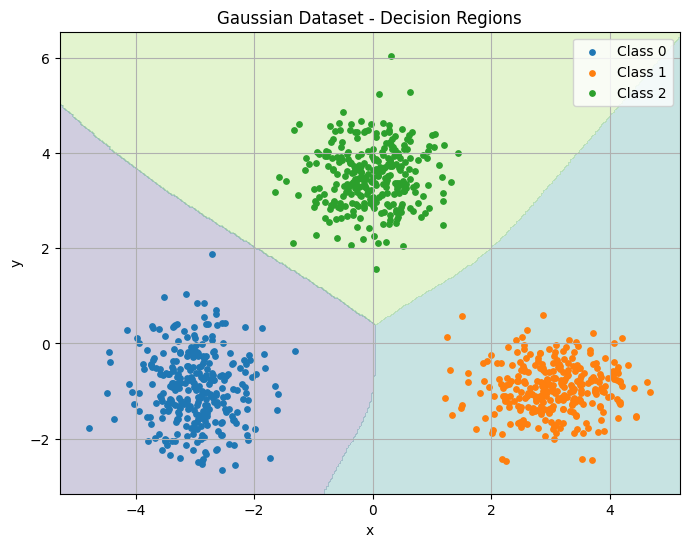

In [35]:
plot_decision_regions(
    best_gaussian_model,
    Xg_train,
    yg_train,
    "Gaussian Dataset - Decision Regions"
)

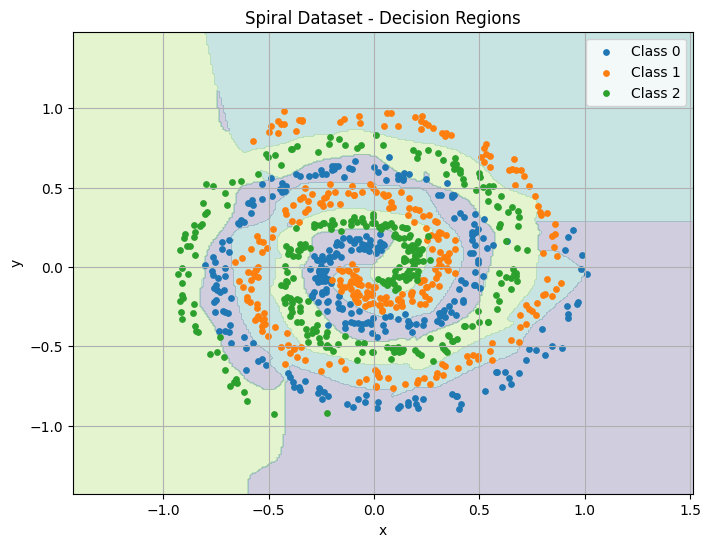

In [36]:
plot_decision_regions(
    best_spiral_model,
    Xs_train,
    ys_train,
    "Spiral Dataset - Decision Regions"
)

In [37]:
def validation_results_all_architectures(
    results,
    X_val,
    y_val,
    dataset_name
):

    print("\n")
    print("=" * 70)
    print(
        dataset_name,
        "- VALIDATION RESULTS"
    )
    print("=" * 70)

    for architecture, result in results.items():

        model = result["model"]

        X_t = torch.tensor(
            X_val,
            dtype=torch.float32
        )

        y_pred = model.predict(
            X_t
        ).numpy()

        cm = confusion_matrix_manual(
            y_val,
            y_pred
        )

        accuracy = np.mean(
            y_val == y_pred
        )

        print("\nArchitecture:", architecture)

        print("Confusion Matrix:")
        print(cm)

        print(
            f"Accuracy: "
            f"{accuracy * 100:.2f}%"
        )

In [38]:
validation_results_all_architectures(
    gaussian_results,
    Xg_val,
    yg_val,
    "Gaussian Dataset"
)


validation_results_all_architectures(
    spiral_results,
    Xs_val,
    ys_val,
    "Spiral Dataset"
)



Gaussian Dataset - VALIDATION RESULTS

Architecture: (4,)
Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]
Accuracy: 100.00%

Architecture: (8,)
Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]
Accuracy: 100.00%

Architecture: (16,)
Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]
Accuracy: 100.00%

Architecture: (32,)
Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]
Accuracy: 100.00%


Spiral Dataset - VALIDATION RESULTS

Architecture: (8, 8)
Confusion Matrix:
[[80  8 12]
 [46 49  5]
 [27 13 60]]
Accuracy: 63.00%

Architecture: (16, 16)
Confusion Matrix:
[[95  2  3]
 [ 9 88  3]
 [ 4  7 89]]
Accuracy: 90.67%

Architecture: (32, 16)
Confusion Matrix:
[[93  1  6]
 [ 6 92  2]
 [ 3  3 94]]
Accuracy: 93.00%

Architecture: (32, 32)
Confusion Matrix:
[[93  1  6]
 [ 5 94  1]
 [ 2  2 96]]
Accuracy: 94.33%



Gaussian Test Set

Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]

Classification Accuracy: 100.00%


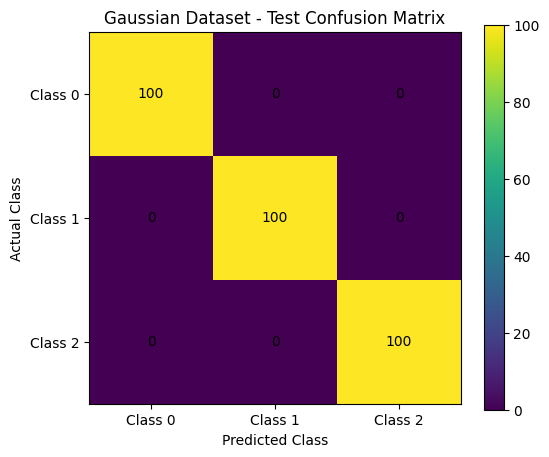

In [39]:
gaussian_test_cm, gaussian_test_accuracy, gaussian_test_pred = (
    classification_results(
        best_gaussian_model,
        Xg_test,
        yg_test,
        "Gaussian Test Set"
    )
)

plot_confusion_matrix(
    gaussian_test_cm,
    "Gaussian Dataset - Test Confusion Matrix"
)


Spiral Test Set

Confusion Matrix:
[[90  4  6]
 [ 6 90  4]
 [ 1  2 97]]

Classification Accuracy: 92.33%


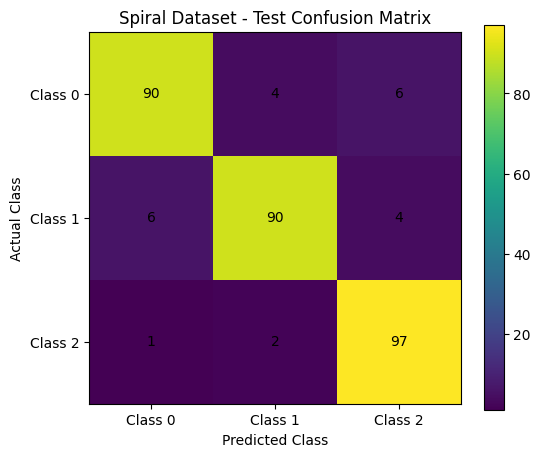

In [40]:
spiral_test_cm, spiral_test_accuracy, spiral_test_pred = (
    classification_results(
        best_spiral_model,
        Xs_test,
        ys_test,
        "Spiral Test Set"
    )
)

plot_confusion_matrix(
    spiral_test_cm,
    "Spiral Dataset - Test Confusion Matrix"
)

In [41]:
def plot_network_outputs(
    model,
    X,
    y,
    dataset_name
):

    X_t = torch.tensor(
        X,
        dtype=torch.float32
    )

    output, activations, pre_activations = (
        model.forward(X_t)
    )

    # ---------------------------------------------
    # Hidden layer outputs
    # ---------------------------------------------

    for layer_index in range(
        1,
        len(activations) - 1
    ):

        hidden_output = (
            activations[layer_index]
            .detach()
            .numpy()
        )

        n_nodes = hidden_output.shape[1]

        ncols = 4
        nrows = int(
            np.ceil(n_nodes / ncols)
        )

        plt.figure(
            figsize=(14, 3 * nrows)
        )

        for node in range(n_nodes):

            plt.subplot(
                nrows,
                ncols,
                node + 1
            )

            for c in range(3):

                mask = y == c

                plt.scatter(
                    X[mask, 0],
                    hidden_output[
                        mask,
                        node
                    ],
                    s=8,
                    label=f"C{c}"
                )

            plt.xlabel("x")
            plt.ylabel(
                f"Hidden Node {node+1}"
            )

            plt.title(
                f"Layer {layer_index}, "
                f"Node {node+1}"
            )

            plt.grid(True)

        plt.suptitle(
            f"{dataset_name} - "
            f"Hidden Layer {layer_index} Outputs"
        )

        plt.tight_layout()
        plt.show()

    # ---------------------------------------------
    # Output layer
    # ---------------------------------------------

    output_np = (
        output.detach().numpy()
    )

    plt.figure(
        figsize=(15, 4)
    )

    for node in range(3):

        plt.subplot(1, 3, node + 1)

        for c in range(3):

            mask = y == c

            plt.scatter(
                X[mask, 0],
                output_np[
                    mask,
                    node
                ],
                s=8,
                label=f"C{c}"
            )

        plt.xlabel("x")
        plt.ylabel(
            f"Output Node {node+1}"
        )

        plt.title(
            f"Output Node {node+1}"
        )

        plt.grid(True)

    plt.suptitle(
        f"{dataset_name} - Output Node Outputs"
    )

    plt.tight_layout()
    plt.show()

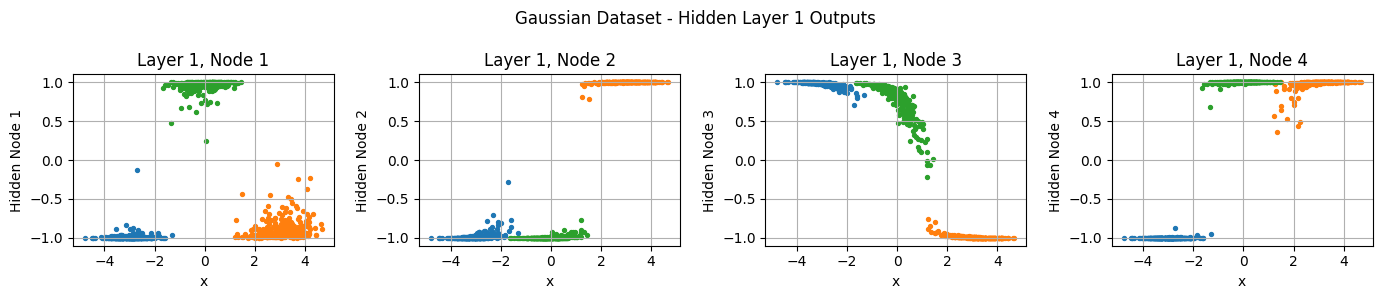

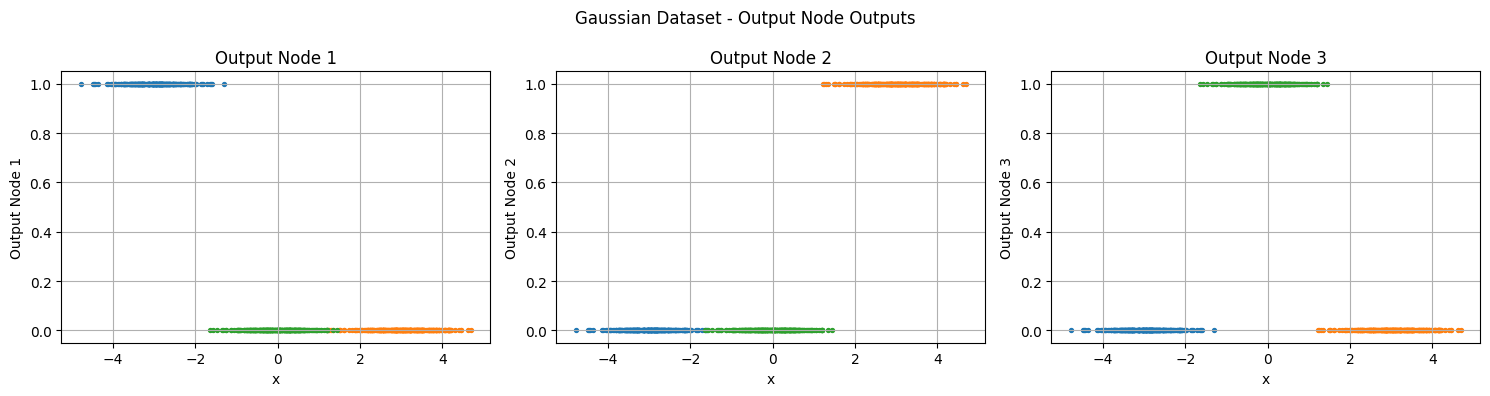

In [42]:
plot_network_outputs(
    best_gaussian_model,
    Xg_train,
    yg_train,
    "Gaussian Dataset"
)

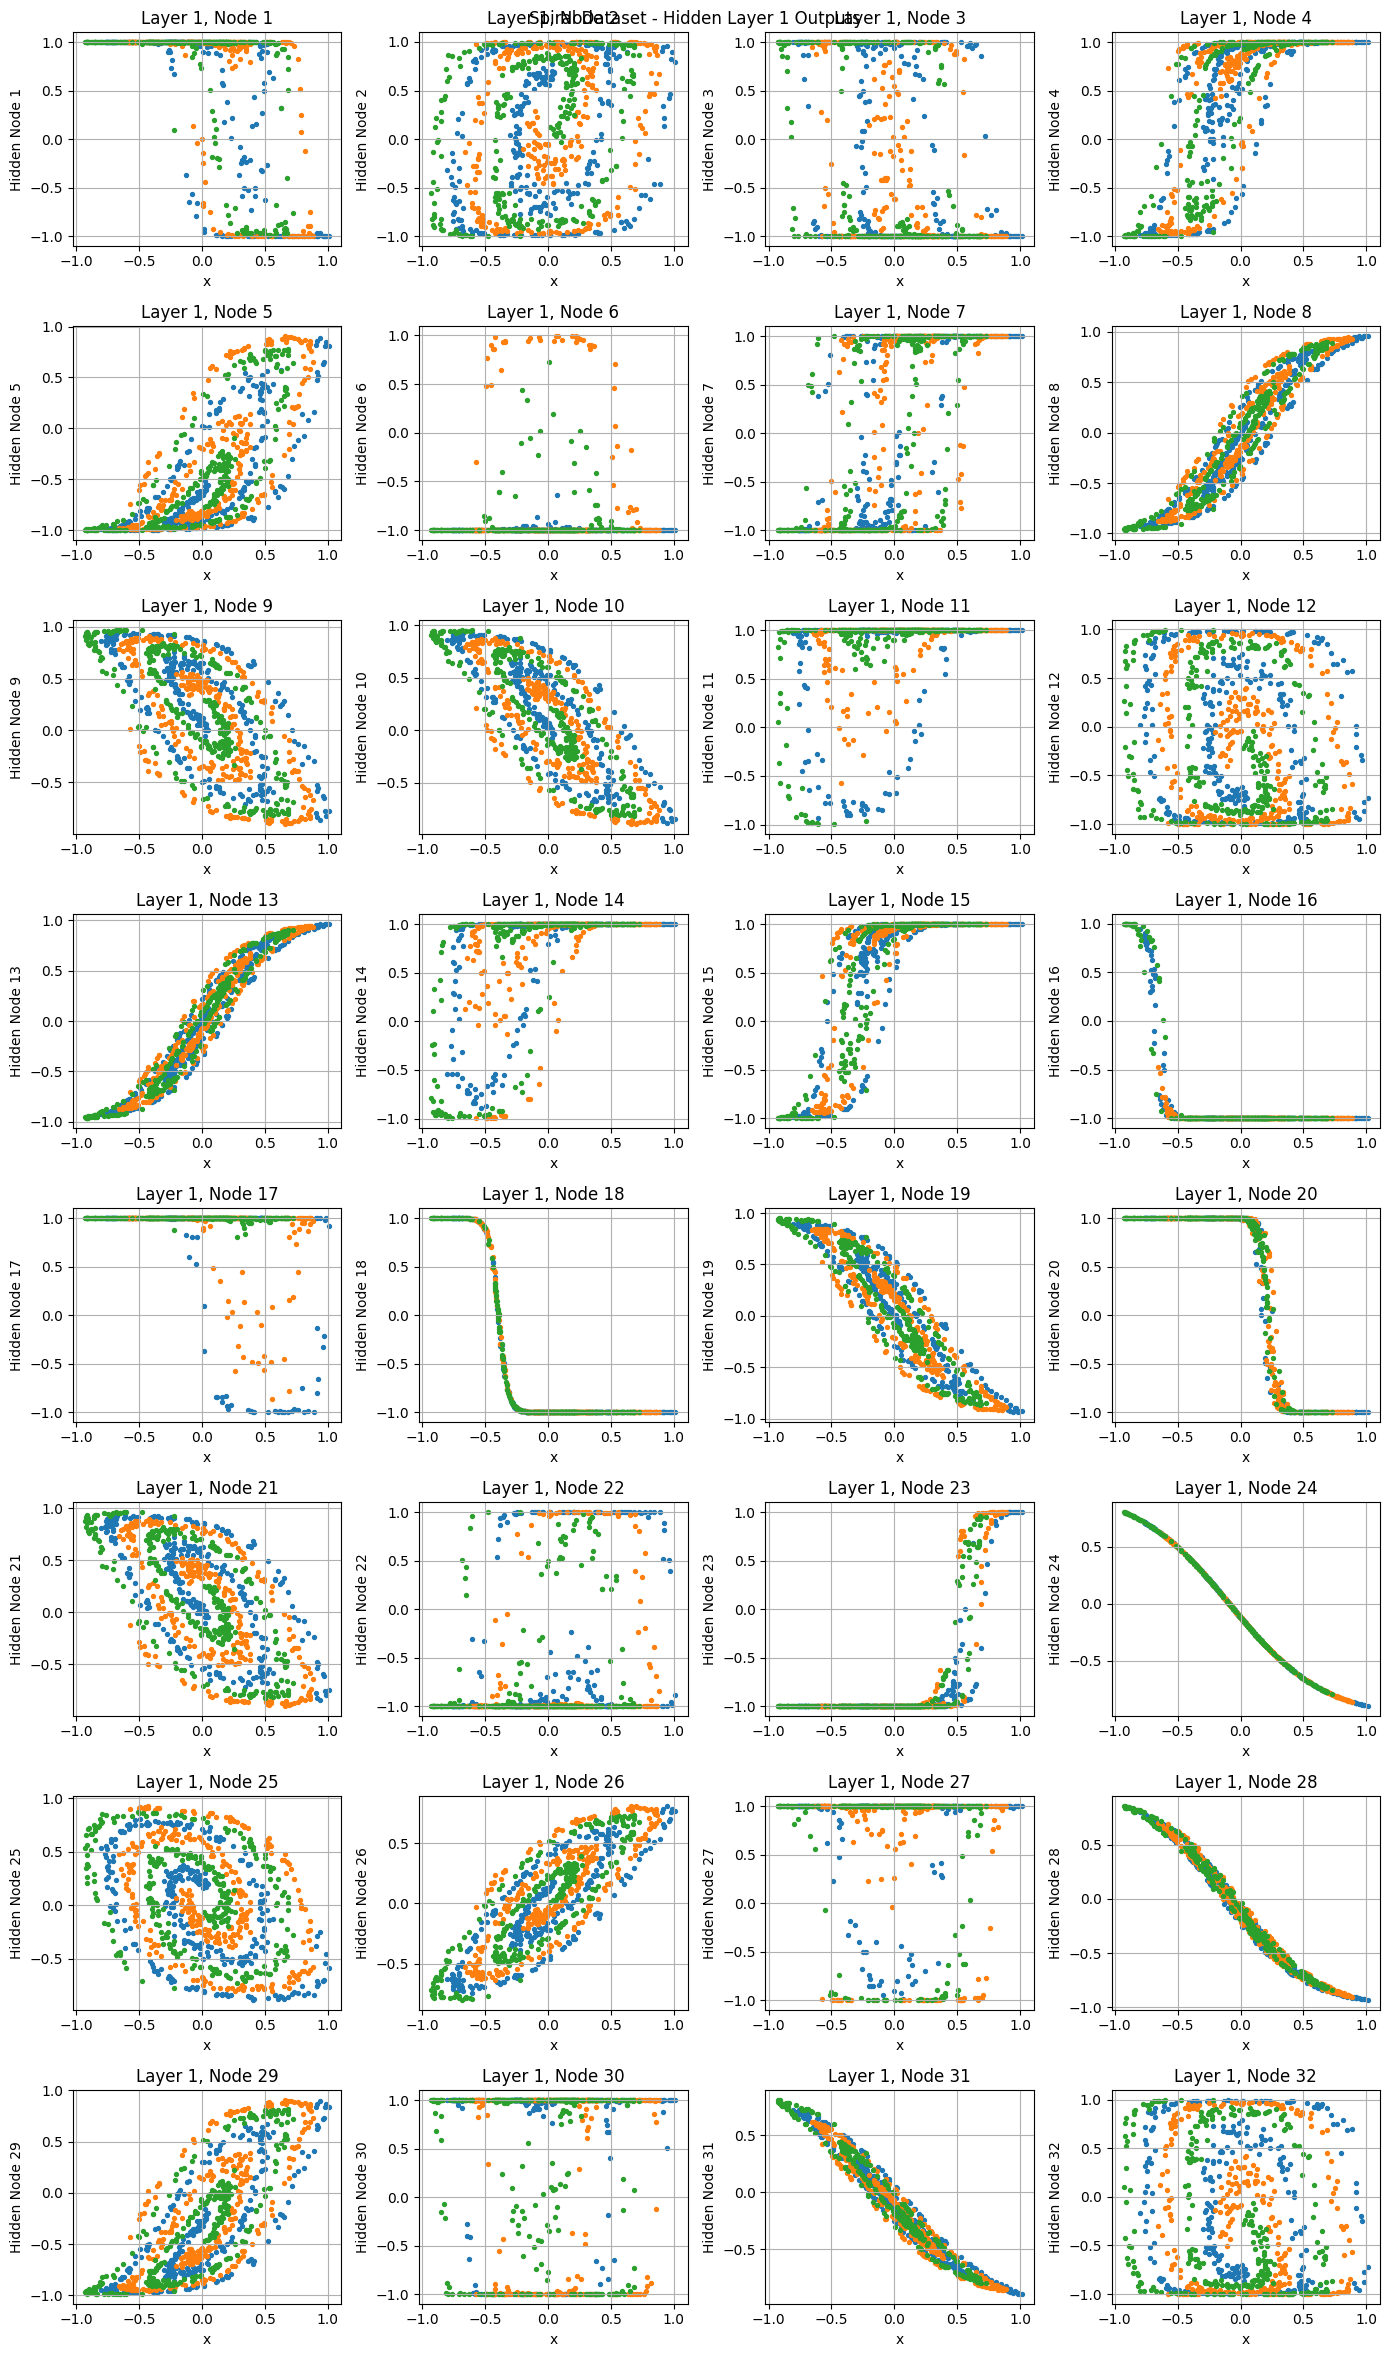

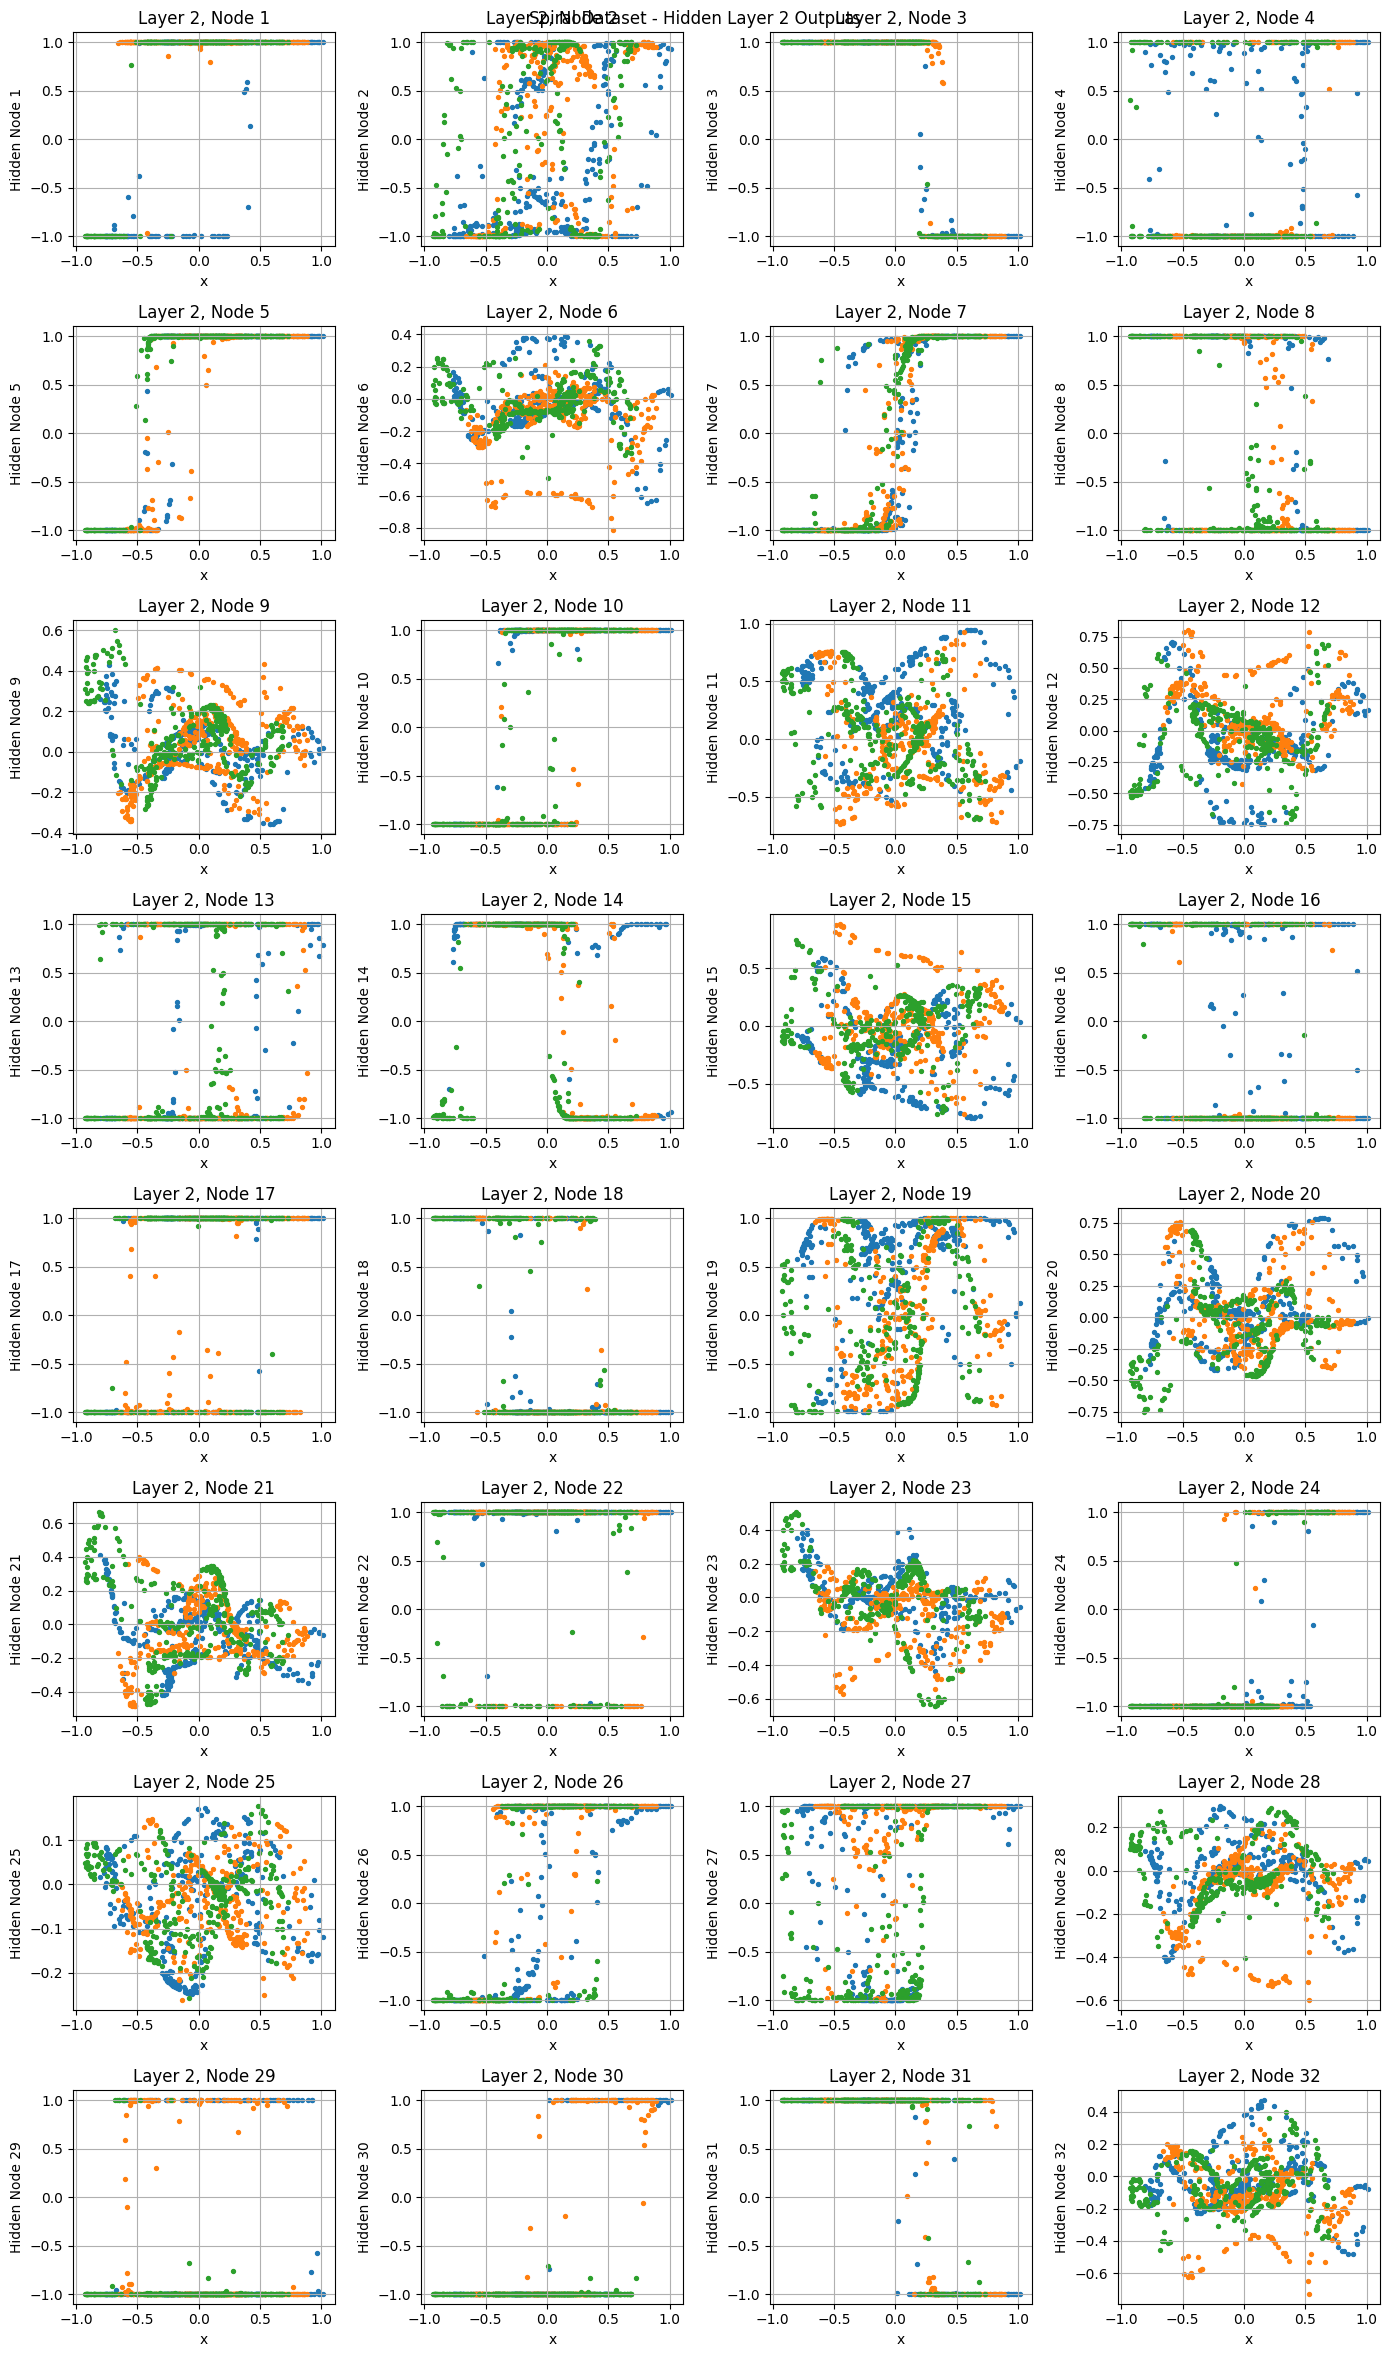

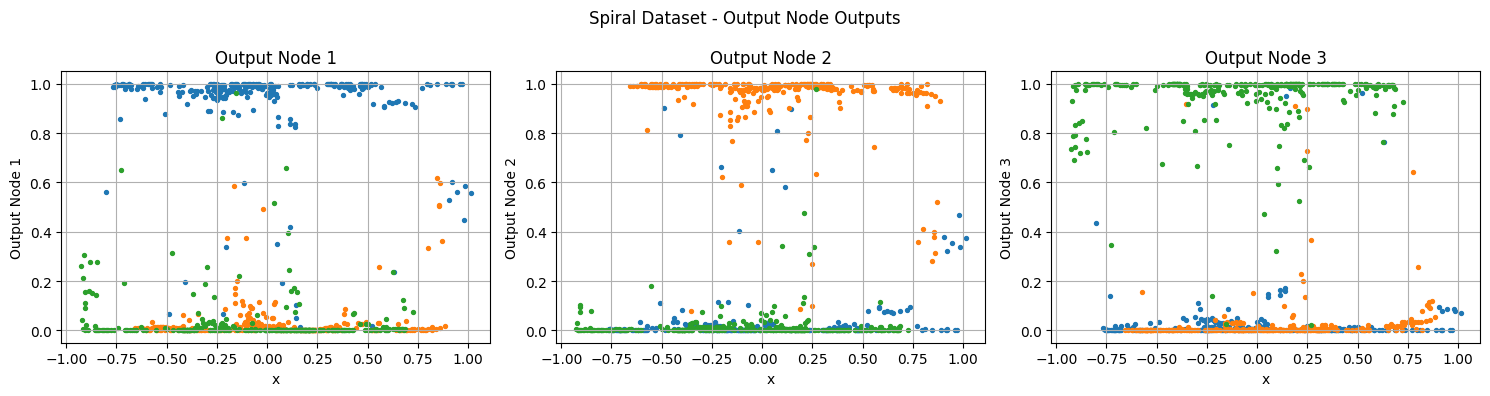

In [43]:
plot_network_outputs(
    best_spiral_model,
    Xs_train,
    ys_train,
    "Spiral Dataset"
)

In [44]:
def plot_hidden_surface(
    model,
    X,
    y,
    dataset_name
):

    X_t = torch.tensor(
        X,
        dtype=torch.float32
    )

    _, activations, _ = model.forward(X_t)

    for layer in range(
        1,
        len(activations) - 1
    ):

        H = activations[layer].detach().numpy()

        for node in range(H.shape[1]):

            plt.figure(figsize=(7, 5))

            scatter = plt.scatter(
                X[:, 0],
                X[:, 1],
                c=H[:, node],
                s=20
            )

            plt.colorbar(
                scatter,
                label=f"Node {node+1} activation"
            )

            plt.xlabel("x")
            plt.ylabel("y")

            plt.title(
                f"{dataset_name}: "
                f"Hidden Layer {layer}, "
                f"Node {node+1}"
            )

            plt.grid(True)
            plt.show()

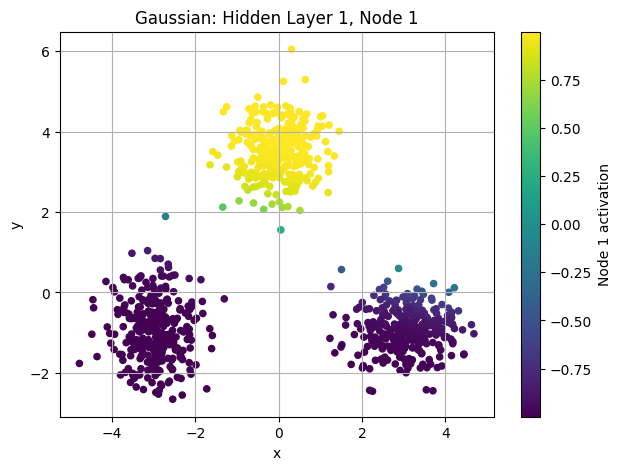

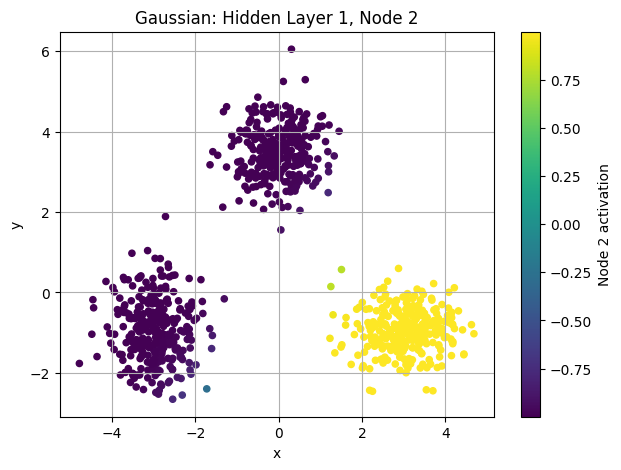

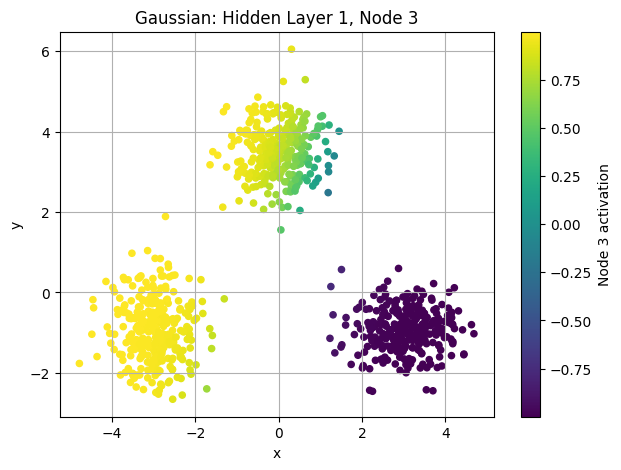

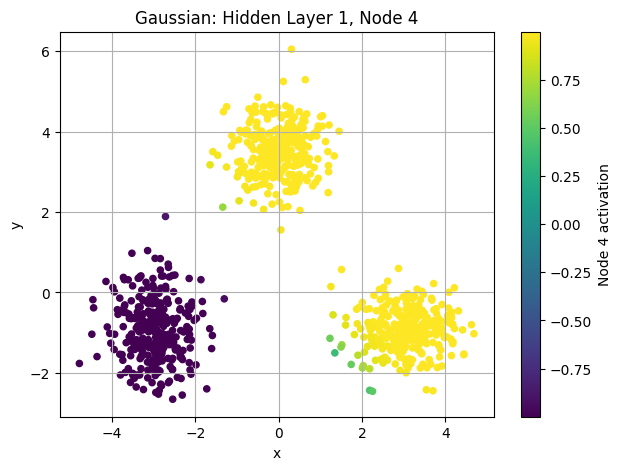

In [45]:
plot_hidden_surface(
    best_gaussian_model,
    Xg_train,
    yg_train,
    "Gaussian"
)

In [46]:
plot_hidden_surface(
    best_spiral_model,
    Xs_train,
    ys_train,
    "Spiral"
)

Output hidden; open in https://colab.research.google.com to view.

In [47]:
class SingleNeuron:

    def __init__(
        self,
        learning_rate=0.01
    ):

        self.learning_rate = learning_rate

        self.w = torch.randn(
            2,
            1
        ) * 0.1

        self.b = torch.zeros(
            1,
            1
        )

    def predict_value(self, X):

        return (
            X @ self.w
            + self.b
        )

    def predict_class(self, X):

        z = self.predict_value(X)

        # Three scalar regions
        prediction = torch.zeros(
            len(X),
            dtype=torch.long
        )

        prediction[
            z[:, 0] >= 0.333
        ] = 1

        prediction[
            z[:, 0] >= 0.666
        ] = 2

        return prediction

    def train(
        self,
        X,
        y,
        epochs=500
    ):

        X_t = torch.tensor(
            X,
            dtype=torch.float32
        )

        # Map class labels to scalar targets
        y_target = torch.tensor(
            y / 2.0,
            dtype=torch.float32
        ).reshape(-1, 1)

        errors = []

        for epoch in range(epochs):

            indices = np.random.permutation(
                len(X)
            )

            total_error = 0

            for idx in indices:

                x = X_t[
                    idx:idx+1
                ]

                target = y_target[
                    idx:idx+1
                ]

                prediction = (
                    x @ self.w
                    + self.b
                )

                error = (
                    prediction
                    - target
                )

                loss = torch.mean(
                    error ** 2
                )

                # Manual gradient
                grad_w = (
                    2 * x.T @ error
                )

                grad_b = (
                    2 * error
                )

                # SGD update
                self.w -= (
                    self.learning_rate
                    * grad_w
                )

                self.b -= (
                    self.learning_rate
                    * grad_b
                )

                total_error += loss.item()

            errors.append(
                total_error / len(X)
            )

        return errors

In [48]:
single_gaussian = SingleNeuron(
    learning_rate=0.01
)

single_gaussian_errors = (
    single_gaussian.train(
        Xg_train,
        yg_train,
        epochs=500
    )
)

Xg_test_t = torch.tensor(
    Xg_test,
    dtype=torch.float32
)

single_gaussian_pred = (
    single_gaussian
    .predict_class(Xg_test_t)
    .numpy()
)

single_gaussian_accuracy = np.mean(
    single_gaussian_pred == yg_test
)

print(
    "Single Neuron Gaussian Test Accuracy:",
    f"{single_gaussian_accuracy*100:.2f}%"
)

Single Neuron Gaussian Test Accuracy: 96.33%


In [49]:
single_spiral = SingleNeuron(
    learning_rate=0.01
)

single_spiral_errors = (
    single_spiral.train(
        Xs_train,
        ys_train,
        epochs=500
    )
)

Xs_test_t = torch.tensor(
    Xs_test,
    dtype=torch.float32
)

single_spiral_pred = (
    single_spiral
    .predict_class(Xs_test_t)
    .numpy()
)

single_spiral_accuracy = np.mean(
    single_spiral_pred == ys_test
)

print(
    "Single Neuron Spiral Test Accuracy:",
    f"{single_spiral_accuracy*100:.2f}%"
)

Single Neuron Spiral Test Accuracy: 33.33%


In [50]:
print("\n")
print("=" * 65)
print("SINGLE NEURON VS FCNN")
print("=" * 65)

print(
    f"Gaussian Single Neuron: "
    f"{single_gaussian_accuracy*100:.2f}%"
)

print(
    f"Gaussian FCNN: "
    f"{gaussian_test_accuracy*100:.2f}%"
)

print()

print(
    f"Spiral Single Neuron: "
    f"{single_spiral_accuracy*100:.2f}%"
)

print(
    f"Spiral FCNN: "
    f"{spiral_test_accuracy*100:.2f}%"
)



SINGLE NEURON VS FCNN
Gaussian Single Neuron: 96.33%
Gaussian FCNN: 100.00%

Spiral Single Neuron: 33.33%
Spiral FCNN: 92.33%


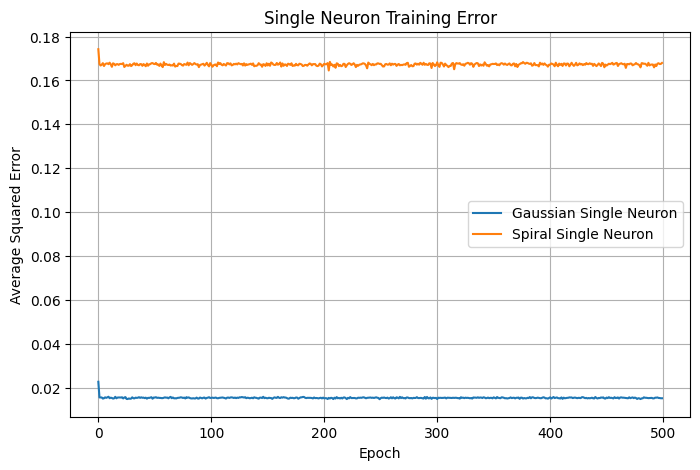

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    single_gaussian_errors,
    label="Gaussian Single Neuron"
)

plt.plot(
    single_spiral_errors,
    label="Spiral Single Neuron"
)

plt.xlabel("Epoch")
plt.ylabel("Average Squared Error")
plt.title("Single Neuron Training Error")

plt.legend()
plt.grid(True)
plt.show()

In [52]:
def plot_single_neuron_regions(
    neuron,
    X,
    y,
    title
):

    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            300
        ),
        np.linspace(
            y_min,
            y_max,
            300
        )
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    grid_t = torch.tensor(
        grid,
        dtype=torch.float32
    )

    pred = (
        neuron.predict_class(grid_t)
        .numpy()
        .reshape(xx.shape)
    )

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        pred,
        alpha=0.25,
        levels=[-0.5, 0.5, 1.5, 2.5]
    )

    for c in range(3):

        mask = y == c

        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            s=15,
            label=f"Class {c}"
        )

    plt.xlabel("x")
    plt.ylabel("y")

    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()

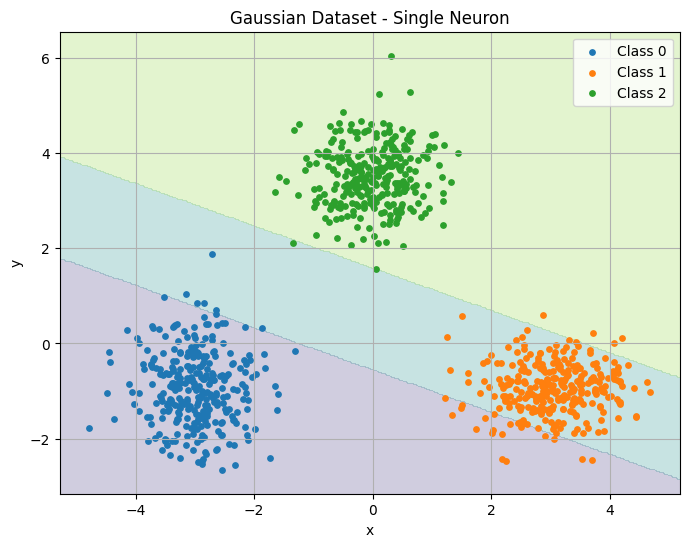

In [53]:
plot_single_neuron_regions(
    single_gaussian,
    Xg_train,
    yg_train,
    "Gaussian Dataset - Single Neuron"
)

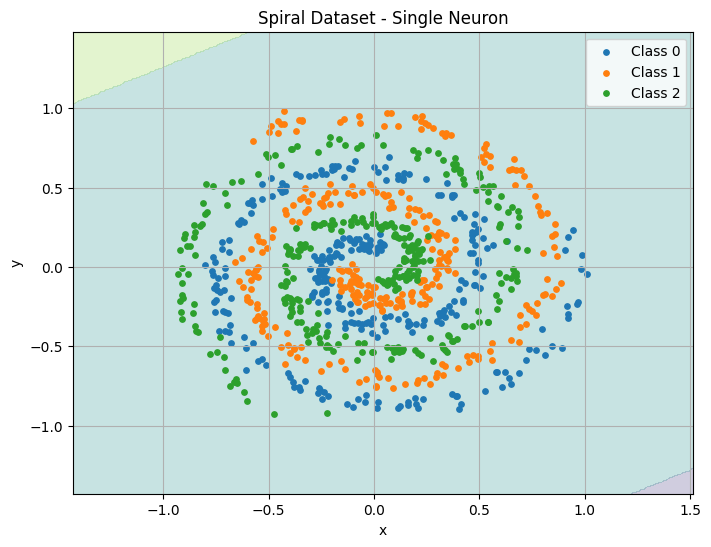

In [54]:
plot_single_neuron_regions(
    single_spiral,
    Xs_train,
    ys_train,
    "Spiral Dataset - Single Neuron"
)

In [55]:
print("\n")
print("=" * 80)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 80)

print(
    f"{'Dataset':<15}"
    f"{'Model':<25}"
    f"{'Accuracy':<15}"
)

print("-" * 80)

print(
    f"{'Gaussian':<15}"
    f"{'Single Neuron':<25}"
    f"{single_gaussian_accuracy*100:.2f}%"
)

print(
    f"{'Gaussian':<15}"
    f"{str(best_gaussian_architecture):<25}"
    f"{gaussian_test_accuracy*100:.2f}%"
)

print(
    f"{'Spiral':<15}"
    f"{'Single Neuron':<25}"
    f"{single_spiral_accuracy*100:.2f}%"
)

print(
    f"{'Spiral':<15}"
    f"{str(best_spiral_architecture):<25}"
    f"{spiral_test_accuracy*100:.2f}%"
)



FINAL PERFORMANCE COMPARISON
Dataset        Model                    Accuracy       
--------------------------------------------------------------------------------
Gaussian       Single Neuron            96.33%
Gaussian       (4,)                     100.00%
Spiral         Single Neuron            33.33%
Spiral         (32, 32)                 92.33%


In [56]:
def generate_inference(
    dataset_name,
    single_accuracy,
    fcnn_accuracy,
    architecture
):

    improvement = (
        fcnn_accuracy
        - single_accuracy
    ) * 100

    print("\n")
    print("=" * 70)
    print(f"INFERENCE — {dataset_name}")
    print("=" * 70)

    print(
        f"Best FCNN architecture: {architecture}"
    )

    print(
        f"Single neuron accuracy: "
        f"{single_accuracy*100:.2f}%"
    )

    print(
        f"FCNN accuracy: "
        f"{fcnn_accuracy*100:.2f}%"
    )

    print(
        f"Improvement: "
        f"{improvement:.2f} percentage points"
    )

    if fcnn_accuracy > single_accuracy:

        print(
            "\nInference: The FCNN performs better "
            "than the single-neuron model."
        )

    else:

        print(
            "\nInference: The single-neuron model "
            "performed competitively."
        )

    if dataset_name == "Spiral":

        print(
            "\nThe spiral dataset is nonlinearly "
            "separable. Therefore, multiple hidden "
            "layers allow the network to construct "
            "complex nonlinear decision boundaries."
        )

    else:

        print(
            "\nThe Gaussian clusters are approximately "
            "linearly separable, so even a relatively "
            "small neural network can achieve good "
            "classification performance."
        )

In [57]:
generate_inference(
    "Gaussian Dataset",
    single_gaussian_accuracy,
    gaussian_test_accuracy,
    best_gaussian_architecture
)

generate_inference(
    "Spiral Dataset",
    single_spiral_accuracy,
    spiral_test_accuracy,
    best_spiral_architecture
)



INFERENCE — Gaussian Dataset
Best FCNN architecture: (4,)
Single neuron accuracy: 96.33%
FCNN accuracy: 100.00%
Improvement: 3.67 percentage points

Inference: The FCNN performs better than the single-neuron model.

The Gaussian clusters are approximately linearly separable, so even a relatively small neural network can achieve good classification performance.


INFERENCE — Spiral Dataset
Best FCNN architecture: (32, 32)
Single neuron accuracy: 33.33%
FCNN accuracy: 92.33%
Improvement: 59.00 percentage points

Inference: The FCNN performs better than the single-neuron model.

The Gaussian clusters are approximately linearly separable, so even a relatively small neural network can achieve good classification performance.
